In [255]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from numpy.linalg import inv
from scipy.optimize import fsolve


In [227]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'png')
plt.rcParams['figure.dpi']=300
plt.rcParams['savefig.dpi']=300

## von Karman flow (Laminar boundary layer over a rotating disk)

In [323]:
def karman_rhs(z, g):
    '''Derivative function for von Karman flow problem'''
    return [g[3], 
            g[4], 
            -2.0*g[0], 
            g[0]*g[0] - (g[1]+1.0)**2 + g[3]*g[2], 
            2.0*g[0]*(g[1]+1.0) + g[4]*g[2], 
            2.0*g[2]*g[0] - 2.0*g[3]]

In [324]:
target1 = 0.0
target2 = -1.0

In [325]:
def objective(g):
    sol = solve_ivp(karman_rhs, [0, 20], [0, 0, 0, g[0], g[1], 0], max_step=0.005)
    return [sol.y[0,-1] - target1,
            sol.y[1,-1] - target2]


In [331]:
root = fsolve(objective, [0.5, -0.6])

In [332]:
root

array([ 0.51023262, -0.61592201])

In [338]:
rootExact = [0.51023262, -0.61592201]

In [333]:
solExact = solve_ivp(karman_rhs, [0, 20], [0, 0, 0, root[0], root[1], 0], max_step=0.005)

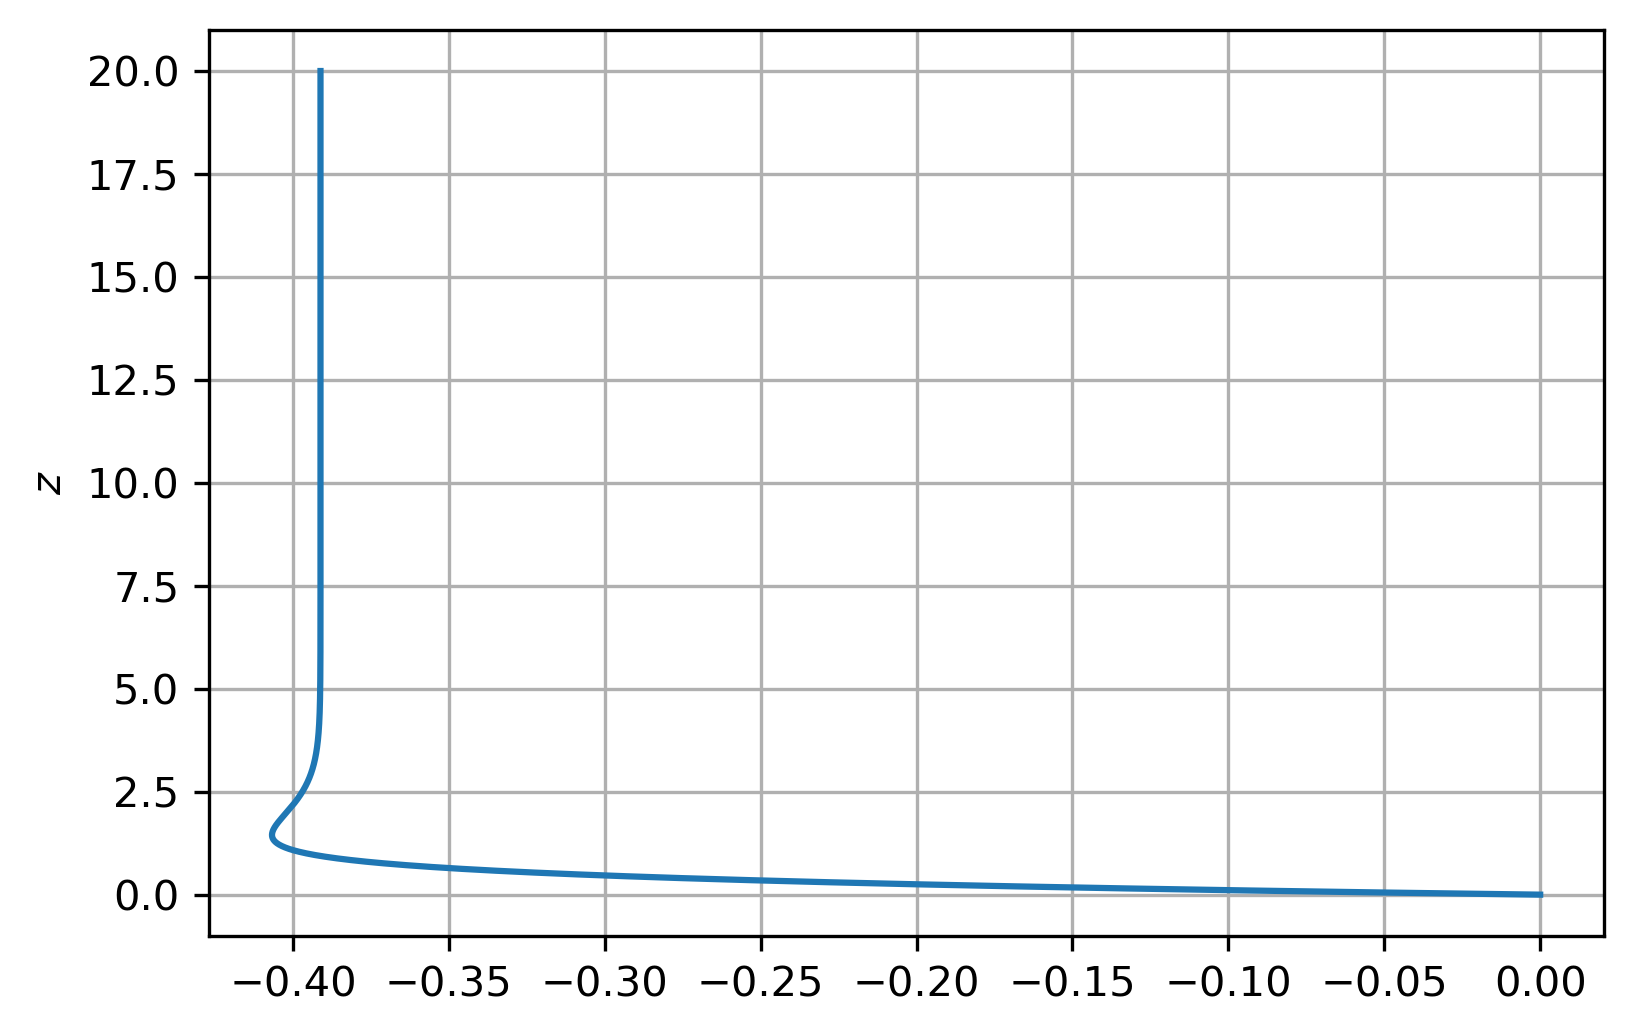

In [337]:
plt.plot(solExact.y[5,:], solExact.t)
plt.ylabel(r'$z$')
plt.grid()
plt.show()

In [339]:
len(solExact.y[0,:])

4002

### via Newton-Raphson

In [340]:
def karman_rhsNewton(z, g):
    '''Derivative function for von Karman flow problem via Newton'''
    return [g[3], 
            g[4], 
            -2.0*g[0], 
            g[0]*g[0] - (g[1]+1.0)**2 + g[3]*g[2], 
            2.0*g[0]*(g[1]+1.0) + g[4]*g[2], 
            2.0*g[2]*g[0] - 2.0*g[3],
            g[8],
            g[9],
            2.0*g[0]*g[6] + g[2]*g[8] + g[3]*g[14] - 2.0*g[1]*g[10] - 2.0*g[10],
            2.0*g[0]*g[7] + g[2]*g[9] + g[3]*g[15] - 2.0*g[1]*g[11] - 2.0*g[11],
            g[12],
            g[13], 
            g[2]*g[12] + g[4]+g[14] + 2.0*g[0]*g[10]  + 2.0*g[1]*g[6] + 2.0*g[6],
            g[2]*g[13] + g[4]+g[15] + 2.0*g[0]*g[11]  + 2.0*g[1]*g[7] + 2.0*g[7],
            -2.0*g[6],
            -2.0*g[7]]

In [341]:
target1 = 0.0
target2 = -1.0

In [350]:
guesses1 = []   # shooting paramter g1
guesses2 = []   # shooting paramter g2

solutionsU = []
solutionsV = []
#solutionsW = []
#solutionsP = []

corrections1 = []
corrections2 = []

In [352]:
guesses1.append(0.52) # initial guess g1
guesses2.append(-0.61) # initial guess g2

#sol = solve_ivp(karman_rhs, [0, 20], [0, 0, 0, guesses1[0], guesses2[0], 0], max_step= 0.1)
sol = solve_ivp(karman_rhsNewton, [0, 20], [0, 0, 0, guesses1[0], guesses2[0], 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0], max_step= 0.005)

solutionsU.append(sol.y[0, -1])
solutionsV.append(sol.y[1, -1])
solutionsW.append(sol.y[2, -1])
solutionsP.append(sol.y[5, -1])

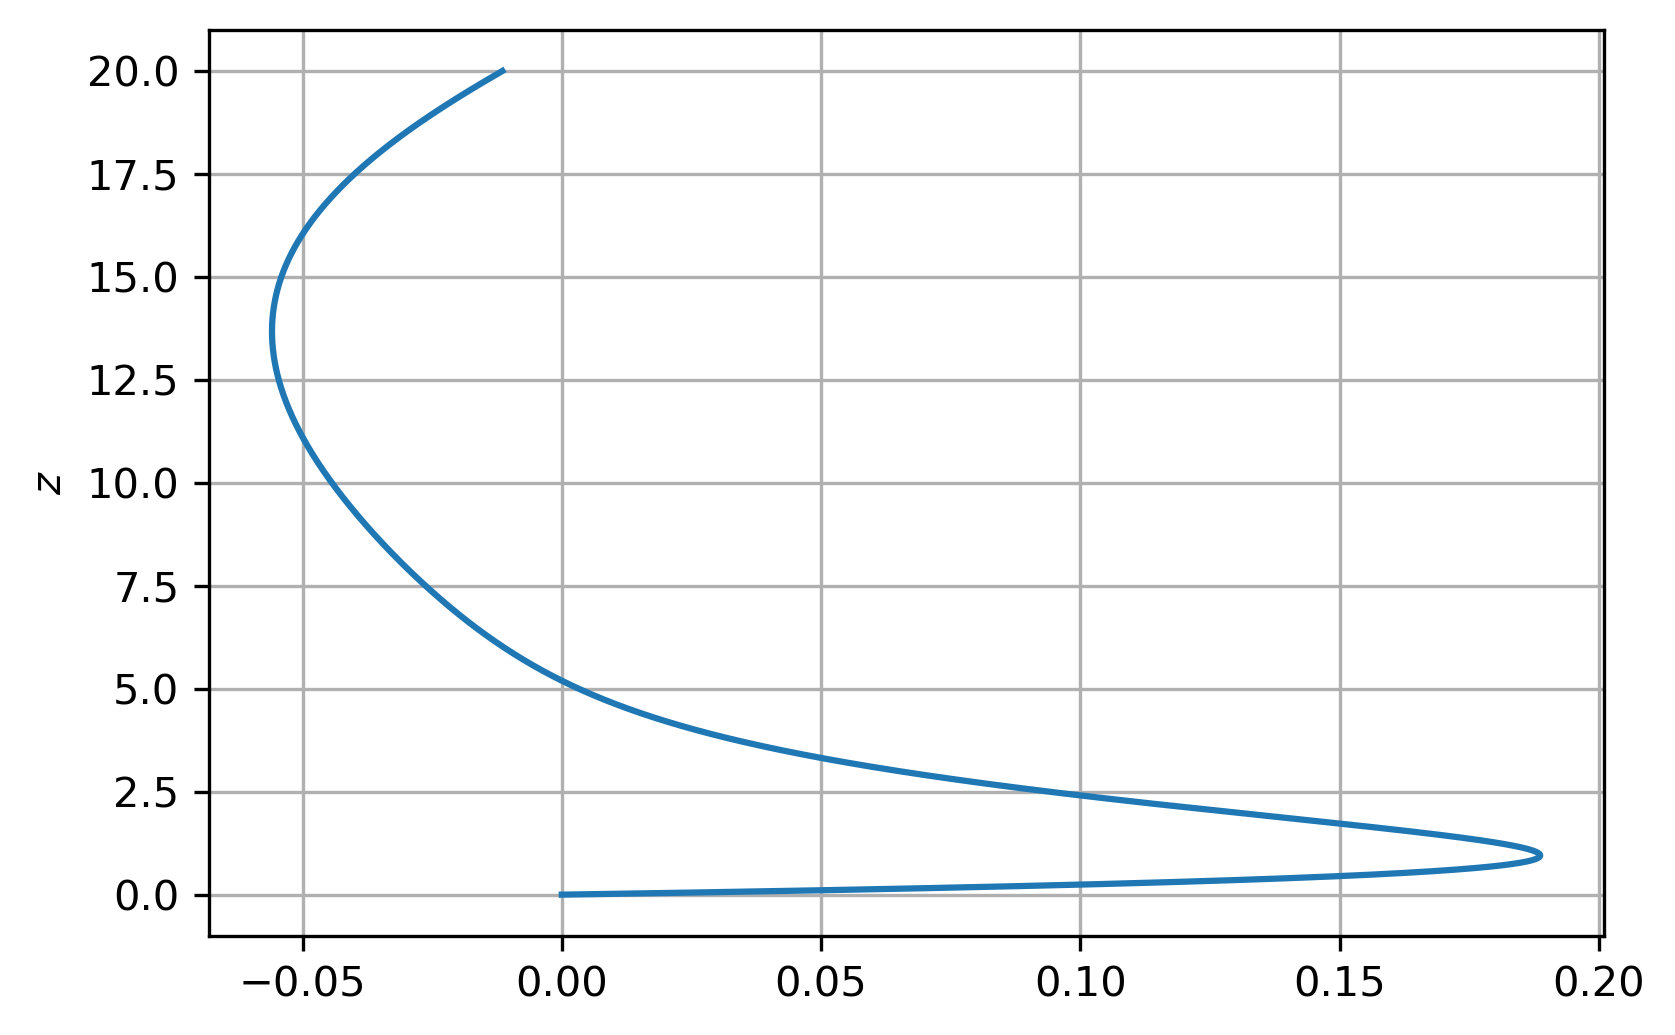

In [353]:
plt.plot(sol.y[0,:], sol.t)
plt.ylabel(r'$z$')
plt.grid()
plt.show()

In [354]:
residualsZ = np.array([ (sol.y[0,-1]) - target1, (sol.y[1,-1]) - target2 ])
residualsZ

array([-0.01146277, -0.04623416])

In [355]:
Jacobian = np.array([ [sol.y[6,-1], sol.y[7,-1]], [sol.y[10,-1], sol.y[11,-1]]])
Jacobian

array([[ -13436.10092071,    6581.69994316],
       [-186706.87456915,   91448.17403952]])

In [356]:
JacInverse = inv(Jacobian)
JacInverse

array([[ 0.64522657, -0.04643819],
       [ 1.31733889, -0.09480046]])

In [357]:
np.allclose(np.dot(Jacobian, JacInverse), np.eye(2))

True

In [358]:
np.allclose(np.dot(JacInverse, Jacobian), np.eye(2))

True

In [359]:
updateh = np.matmul(JacInverse, residualsZ)

In [360]:
corrections1.append(updateh[0])
corrections2.append(updateh[1])

In [361]:
convCrit = 1e-9
while np.abs(residualsZ[0]) > convCrit or np.abs(residualsZ[1]) > convCrit :
    guesses1.append(guesses1[-1] + corrections1[-1]) 
    guesses2.append(guesses2[-1] + corrections2[-1]) 

    sol = solve_ivp(karman_rhsNewton, [0, 20], [0, 0, 0, guesses1[-1], guesses2[-1], 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0], max_step= 0.005)

    solutionsU.append(sol.y[0, -1])
    solutionsV.append(sol.y[1, -1])
    solutionsW.append(sol.y[2, -1])
    solutionsP.append(sol.y[5, -1])

    residualsZ = np.array([ solutionsU[-1] - target1, solutionsV[-1] - target2 ])

    Jacobian = np.array([ [sol.y[6,-1], sol.y[7,-1]], [sol.y[10,-1], sol.y[11,-1]]])
    JacInverse = inv(Jacobian)

    updateh = np.matmul(JacInverse, residualsZ)
    corrections1.append(updateh[0])
    corrections2.append(updateh[1])


    if len(solutionsU) >= 1e1:
        break 

In [362]:
print('tries guesses1 solutionsU guesses2 solutionsV')
for idx, (g1, sU, g2, sV) in enumerate(zip(guesses1, solutionsU, guesses2, solutionsV)):
    print(f'{idx:3d}   {g1:6.4f}   {sU:6.4f}    {g2:6.4f}  {sV:6.4f}')

print(f'Number of iterations required: {len(solutions)}')

tries guesses1 solutionsU guesses2 solutionsV
  0   0.5200   -0.0115    -0.6100  -1.0462
  1   0.5200   -0.0115    -0.6100  -1.0462
  2   0.5148   0.0320    -0.6207  -0.9277
  3   0.2474   -2619110870933563855503097856.0000    -1.1771  -335891574342810271744.0000
  4   -0.8520   -52746904500312803965528965120.0000    4.1629  7415520086624125845504.0000
  5   1.3828   -11417316751722864058086457344.0000    3.0386  2194029869992527790080.0000
  6   2.2106   -9197051078992200214589210624.0000    2.5090  2041680882868015857664.0000
  7   2.7494   -7091800217249868676734124032.0000    2.0616  1847307214256800268288.0000
  8   3.1292   -16363673799910905081808027648.0000    1.5622  4265397840655527968768.0000
  9   3.1329   -7121323843337369494082289664.0000    2.3321  1918300980007745355776.0000
Number of iterations required: 0
